# Phase 1 — Prétraitement des données

**Input** : `laptop.csv`  
**Output** : `laptop_phase1.csv`

Étapes :
1. Chargement des données
2. Exploration initiale
3. Suppression des colonnes inutiles
4. Filtrage des produits hors-sujet
5. Suppression des doublons
6. Gestion des valeurs manquantes
7. Normalisation & nettoyage (+ extraction `ram_gb` depuis le titre)
8. Visualisation rapide
9. Export

In [1]:
import sys, os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

INPUT_PATH  = '../inputs/laptop.csv'
OUTPUT_DIR  = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Setup terminé')

✅ Setup terminé


## 1. Chargement des données

In [2]:
df = pd.read_csv(INPUT_PATH)

print(f'Shape initial : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape initial : (192, 20)
Colonnes : ['title', 'price', 'price_raw', 'currency', 'platform', 'url', 'image', 'seller', 'sku', 'category', 'category_hint', 'attributes', 'match_reason', 'search_query', 'subcategory', 'price_usd', 'rating', 'reviews_count', 'scraped_at', 'id']


,title,price,price_raw,currency,platform,url,image,seller,sku,category,category_hint,attributes,match_reason,search_query,subcategory,price_usd,rating,reviews_count,scraped_at,id
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",5799.0,5799.0,MAD,jumia,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,https://ma.jumia.is/unsafe/fit-in/300x300/filt...,Jumia,HP017EL0TBB6ENAFAMZ,electronics,NaN,{},POSITIVE: 'laptop',laptop,laptop,579.9,NaN,0,2026-05-13T14:44:00.784180Z,NaN
1,"DELL Laptop LATITUDE 7420 i5-11th , RAM 16 Go,...",5500.0,5500.0,MAD,jumia,https://www.jumia.ma/dell-laptop-latitude-7420...,https://ma.jumia.is/unsafe/fit-in/300x300/filt...,Jumia,DE014CL0UG48INAFAMZ,electronics,NaN,{},POSITIVE: 'laptop',laptop,laptop,550.0,NaN,0,2026-05-13T14:44:00.784201Z,NaN
2,DELL laptop latitude i5 8eme génération 8G RAM...,3400.0,3400.0,MAD,jumia,https://www.jumia.ma/dell-laptop-latitude-i5-8...,https://ma.jumia.is/unsafe/fit-in/300x300/filt...,Jumia,DE014CL02J9GKNAFAMZ,electronics,NaN,{},POSITIVE: 'laptop',laptop,laptop,340.0,NaN,0,2026-05-13T14:44:00.784209Z,NaN


In [4]:
df['platform'].unique()

<StringArray>
['jumia', 'aliexpress']
Length: 2, dtype: str

## 2. Exploration initiale

In [5]:
print('=== Types de données ===')
print(df.dtypes)
print()
print('=== Valeurs manquantes ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'manquants': missing, '%': missing_pct})[missing > 0])
print()
print('=== Distribution par plateforme ===')
print(df['platform'].value_counts())
print()
print('=== Stats prix bruts ===')
print(df['price'].describe())

=== Types de données ===
title                str
price            float64
price_raw        float64
currency             str
platform             str
url                  str
image                str
seller               str
sku                  str
category             str
category_hint    float64
attributes           str
match_reason         str
search_query         str
subcategory          str
price_usd        float64
rating           float64
reviews_count      int64
scraped_at           str
id               float64
dtype: object

=== Valeurs manquantes ===
               manquants      %
image                184   95.8
seller               184   95.8
sku                  184   95.8
category_hint        192  100.0
match_reason         184   95.8
subcategory            4    2.1
rating               192  100.0
id                     8    4.2

=== Distribution par plateforme ===
platform
aliexpress    184
jumia           8
Name: count, dtype: int64

=== Stats prix bruts ===
count      

## 3. Suppression des colonnes inutiles

Colonnes supprimées :
- `price_raw` : doublon de `price`
- `attributes` : **100 % vide** `{}`
- `match_reason` : métadonnée scraping, 96 % NaN
- `sku`, `image`, `seller` : 96 % NaN, inutiles pour DM
- `subcategory`, `category_hint` : trop de manquants ou redondant
- `rating` : **100 % NaN** → aucune valeur exploitable
- `reviews_count` : **100 % à 0** → aucune variance

In [6]:
COLS_TO_DROP = [
    'price_raw', 'attributes', 'match_reason', 'sku',
    'image', 'seller', 'subcategory', 'category_hint',
    'rating', 'reviews_count'  # 100% NaN / 100% zéro : aucune info
]

df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

print(f'Colonnes restantes ({len(df.columns)}) : {list(df.columns)}')
df.info()

Colonnes restantes (10) : ['title', 'price', 'currency', 'platform', 'url', 'category', 'search_query', 'price_usd', 'scraped_at', 'id']
<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         192 non-null    str    
 1   price         192 non-null    float64
 2   currency      192 non-null    str    
 3   platform      192 non-null    str    
 4   url           192 non-null    str    
 5   category      192 non-null    str    
 6   search_query  192 non-null    str    
 7   price_usd     192 non-null    float64
 8   scraped_at    192 non-null    str    
 9   id            184 non-null    float64
dtypes: float64(3), str(7)
memory usage: 15.1 KB


## 4. Filtrage des produits hors-sujet

In [7]:
print('Produits AVANT filtrage :', len(df))

LAPTOP_KEYWORDS = [
    'laptop', 'notebook', 'pc portable', 'netbook', 'ultrabook',
    'thinkpad', 'ideapad', 'macbook', 'chromebook', 'vivobook',
    'zenbook', 'inspiron', 'latitude', 'elitebook', 'probook',
    'pavilion', 'envy', 'spectre', 'stealth', 'predator', 'rog',
    'swift', 'aspire', 'nitro', 'legion', 'gram', 'thinkbook',
    'redmibook', 'magicbook', 'matebook'
]

EXCLUDE_KEYWORDS = [
    'ram ', 'ddr4', 'ddr5', 'sodimm', 'dimm',
    'power bank', 'powerbank', 'batterie externe',
    'souris', 'mouse', 'clavier', 'keyboard',
    'ssd externe', 'external ssd', 'external hard',
    'portable ssd', 'usb hub', 'webcam', 'casque',
    'écouteur', 'headphone', 'cooling pad', 'ventilateur', 'monitor'
]

title_lower = df['title'].str.lower()
mask_include = title_lower.str.contains('|'.join(LAPTOP_KEYWORDS), na=False)
mask_exclude = title_lower.str.contains('|'.join(EXCLUDE_KEYWORDS), na=False)

df = df[mask_include & ~mask_exclude].copy()

print('Produits APRÈS filtrage :', len(df))
print()
print('Distribution par plateforme après filtrage :')
print(df['platform'].value_counts())

Produits AVANT filtrage : 192
Produits APRÈS filtrage : 55

Distribution par plateforme après filtrage :
platform
aliexpress    53
jumia          2
Name: count, dtype: int64


## 5. Suppression des doublons

In [8]:
print('Doublons avant :', df.duplicated().sum())

df = df.drop_duplicates(subset=['url'], keep='first')
df = df.drop_duplicates(subset=['title', 'price', 'platform'], keep='first')
df = df.reset_index(drop=True)

print('Doublons après :', df.duplicated().sum())
print('Produits restants :', len(df))

Doublons avant : 0
Doublons après : 0
Produits restants : 55


## 6. Gestion des valeurs manquantes

In [9]:
# Prix manquants → supprimer
before = len(df)
df = df.dropna(subset=['price'])
print(f'Lignes supprimées (prix nul) : {before - len(df)}')

# search_query manquant → 'laptop'
df['search_query'] = df['search_query'].fillna('laptop')

print('\nValeurs manquantes restantes :')
print(df.isnull().sum()[df.isnull().sum() > 0])

Lignes supprimées (prix nul) : 0

Valeurs manquantes restantes :
id    2
dtype: int64


## 7. Normalisation & Nettoyage

**Extraction** : `ram_gb` et `storage_gb` depuis le titre.  
Logique : les valeurs RAM sont dans un ensemble fixe `{2,4,6,8,12,16,24,32,48,64,128}`, le stockage est toujours ≥ 128 Go ou en TB.

In [10]:
# --- 7.1 Prix ---
USD_TO_MAD = 10.0
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price_usd'] = (df['price'] / USD_TO_MAD).round(2)

# Fourchette réaliste laptop
before = len(df)
df = df[(df['price'] >= 1500) & (df['price'] <= 80000)]
print(f'Produits supprimés (prix hors 1500-80 000 MAD) : {before - len(df)}')

# --- 7.2 Nettoyage titre ---
df['title'] = df['title'].str.strip().str.replace(r'\s+', ' ', regex=True)

# --- 7.3 Extraction marque ---
BRANDS = ['HP', 'Dell', 'Lenovo', 'Asus', 'Acer', 'Apple', 'MSI', 'Samsung',
          'Huawei', 'Honor', 'Xiaomi', 'Razer', 'LG', 'Toshiba', 'Sony',
          'Microsoft', 'GPD', 'Chuwi', 'Jumper', 'Carbayta']

def extract_brand(title):
    for brand in BRANDS:
        if brand.lower() in title.lower():
            return brand
    return 'Other'

df['brand'] = df['title'].apply(extract_brand)

# --- 7.4 Extraction RAM + Stockage depuis le titre ---
def extract_ram_storage(title):
    """
    Extrait RAM et stockage depuis le titre.
    Logique : on collecte toutes les valeurs en Go/GB/TB,
    RAM = valeur dans l'ensemble fixe {2,4,6,8,12,16,24,32,48,64,128}
    Stockage = valeur >= 128 Go (256, 512, 1024...)
    """
    RAM_VALID = {2, 4, 6, 8, 12, 16, 24, 32, 48, 64, 128}
    values_gb = []

    # Capturer les TB → convertir en Go
    for m in re.finditer(r'(\d+(?:\.\d+)?)\s*[Tt][Bb]', title):
        values_gb.append(float(m.group(1)) * 1024)

    # Capturer tous les Go/GB
    for m in re.finditer(r'(\d+)\s*[Gg][OoBb]', title):
        values_gb.append(int(m.group(1)))

    # Capturer Xg seul (ex: 8G RAM, 16G+)
    for m in re.finditer(r'(\d+)[Gg](?:\s|\+|-|/|$)', title):
        values_gb.append(int(m.group(1)))

    if not values_gb:
        return None, None

    ram_candidates     = sorted([v for v in values_gb if v in RAM_VALID])
    storage_candidates = sorted([v for v in values_gb if v >= 64], reverse=True)

    ram     = ram_candidates[0]     if ram_candidates     else None
    storage = storage_candidates[0] if storage_candidates else None

    return ram, storage

df[['ram_gb', 'storage_gb']] = df['title'].apply(
    lambda t: pd.Series(extract_ram_storage(t))
)

print(f'RAM      — couverture : {df["ram_gb"].notna().sum()}/{len(df)} ({df["ram_gb"].notna().mean()*100:.0f}%)')
print(f'Stockage — couverture : {df["storage_gb"].notna().sum()}/{len(df)} ({df["storage_gb"].notna().mean()*100:.0f}%)')
print()
print('Distribution RAM (Go) :')
print(df['ram_gb'].value_counts(dropna=False).sort_index())
print()
print('Distribution Stockage (Go) :')
print(df['storage_gb'].value_counts(dropna=False).sort_index())

# --- 7.5 Date ---
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')
df['scraped_date'] = df['scraped_at'].dt.date

# --- 7.6 Nettoyage URL ---
df['url'] = df['url'].apply(lambda x: x.split('?')[0] if isinstance(x, str) else x)

print('\n✅ Nettoyage terminé')
print(f'Shape final : {df.shape}')

Produits supprimés (prix hors 1500-80 000 MAD) : 5
RAM      — couverture : 38/50 (76%)
Stockage — couverture : 33/50 (66%)

Distribution RAM (Go) :
ram_gb
4.0      1
8.0      2
16.0    16
24.0     2
32.0    14
64.0     3
NaN     12
Name: count, dtype: int64

Distribution Stockage (Go) :
storage_gb
128.0      1
512.0     11
1024.0    13
2048.0     8
NaN       17
Name: count, dtype: int64

✅ Nettoyage terminé
Shape final : (50, 14)


In [11]:
print('=== RÉSUMÉ FINAL ===')
print(f'Nombre de produits : {len(df)}')
print(f'Plateformes : {df["platform"].unique()}')
print(f'Marques : {df["brand"].value_counts().head(10).to_dict()}')
print()
print('=== STATS PRIX (MAD) ===')
print(df['price'].describe().round(2))
print()
print(f'ram_gb renseignée     : {df["ram_gb"].notna().sum()}/{len(df)} lignes')
print(f'storage_gb renseignée : {df["storage_gb"].notna().sum()}/{len(df)} lignes')
df.head()

=== RÉSUMÉ FINAL ===
Nombre de produits : 50
Plateformes : <StringArray>
['jumia', 'aliexpress']
Length: 2, dtype: str
Marques : {'Other': 14, 'Xiaomi': 8, 'Lenovo': 6, 'Honor': 5, 'Acer': 5, 'Huawei': 5, 'GPD': 3, 'HP': 2, 'MSI': 2}

=== STATS PRIX (MAD) ===
count       50.00
mean     13708.18
std       9615.94
min       2602.93
25%       6603.82
50%      12624.84
75%      17308.22
max      45362.04
Name: price, dtype: float64

ram_gb renseignée     : 38/50 lignes
storage_gb renseignée : 33/50 lignes


,title,price,currency,platform,url,category,search_query,price_usd,scraped_at,id,brand,ram_gb,storage_gb,scraped_date
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",5799.00,MAD,jumia,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,electronics,laptop,579.90,2026-05-13 14:44:00.784180+00:00,NaN,HP,8.0,512.0,2026-05-13
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,4099.00,MAD,jumia,https://www.jumia.ma/lenovo-thinkpad-x13-yoga-...,electronics,laptop,409.90,2026-05-13 14:44:00.784216+00:00,NaN,Lenovo,16.0,512.0,2026-05-13
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,39218.93,MAD,aliexpress,https://www.aliexpress.com/item/10050116276281...,electronics,laptop,3921.89,2026-05-13 14:44:00.784334+00:00,1.005012e+15,MSI,64.0,2048.0,2026-05-13
4,GPD Micro PC 2 Beastly Handheld Mini Laptop: 7...,9521.78,MAD,aliexpress,https://www.aliexpress.com/item/10050121750161...,electronics,laptop,952.18,2026-05-13 14:44:00.784459+00:00,1.005012e+15,GPD,16.0,512.0,2026-05-13
5,FIREBAT 16Pro Gaming Laptop 16Inch AMD Ryzen 7...,13005.25,MAD,aliexpress,https://www.aliexpress.com/item/10050102411682...,electronics,laptop,1300.53,2026-05-13 14:44:00.784733+00:00,1.005010e+15,Other,NaN,NaN,2026-05-13


## 8. Visualisation rapide

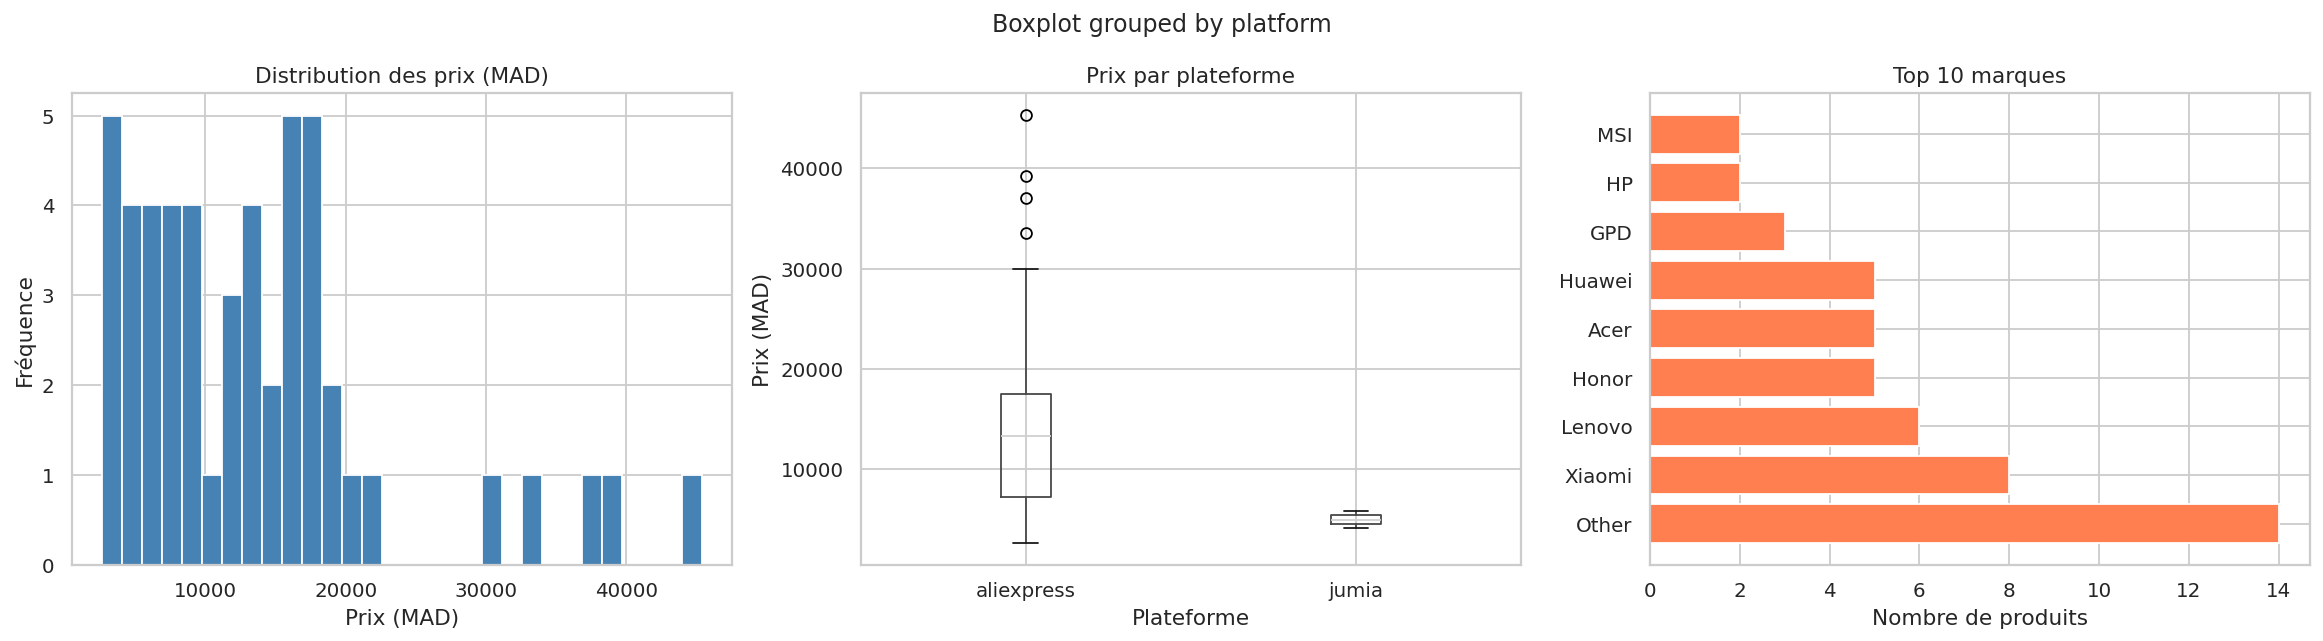

✅ Graphique sauvegardé


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution des prix
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des prix (MAD)')
axes[0].set_xlabel('Prix (MAD)')
axes[0].set_ylabel('Fréquence')

# Prix par plateforme
df.boxplot(column='price', by='platform', ax=axes[1])
axes[1].set_title('Prix par plateforme')
axes[1].set_xlabel('Plateforme')
axes[1].set_ylabel('Prix (MAD)')
plt.sca(axes[1])
plt.title('Prix par plateforme')

# Produits par marque
brand_counts = df['brand'].value_counts().head(10)
axes[2].barh(brand_counts.index, brand_counts.values, color='coral')
axes[2].set_title('Top 10 marques')
axes[2].set_xlabel('Nombre de produits')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase1_visualisation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

## 9. Export

In [14]:
FINAL_COLS = ['title', 'brand', 'price', 'price_usd', 'currency',
              'platform', 'ram_gb', 'storage_gb', 'category', 'search_query',
              'url', 'scraped_date']

df_final = df[[c for c in FINAL_COLS if c in df.columns]].copy()

df_final.to_csv('../inputs/laptop_phase1.csv', index=False, encoding='utf-8')

print(f'✅ Fichier exporté : laptop_phase1.csv')
print(f'Shape final : {df_final.shape}')
print(f'Colonnes : {list(df_final.columns)}')
df_final.head()

✅ Fichier exporté : laptop_phase1.csv
Shape final : (50, 12)
Colonnes : ['title', 'brand', 'price', 'price_usd', 'currency', 'platform', 'ram_gb', 'storage_gb', 'category', 'search_query', 'url', 'scraped_date']


,title,brand,price,price_usd,currency,platform,ram_gb,storage_gb,category,search_query,url,scraped_date
0,"Hp Laptop 15-FC0075k - Ecran FHD 15,6""- Ryzen5...",HP,5799.00,579.90,MAD,jumia,8.0,512.0,electronics,laptop,https://www.jumia.ma/hp-laptop-15-fc0075k-ecra...,2026-05-13
1,Lenovo ThinkPad X13 Yoga Gen 1 Convertible Lap...,Lenovo,4099.00,409.90,MAD,jumia,16.0,512.0,electronics,laptop,https://www.jumia.ma/lenovo-thinkpad-x13-yoga-...,2026-05-13
2,2025 MSI Stealth 18 HX AI Gaming Laptop 18 Inc...,MSI,39218.93,3921.89,MAD,aliexpress,64.0,2048.0,electronics,laptop,https://www.aliexpress.com/item/10050116276281...,2026-05-13
4,GPD Micro PC 2 Beastly Handheld Mini Laptop: 7...,GPD,9521.78,952.18,MAD,aliexpress,16.0,512.0,electronics,laptop,https://www.aliexpress.com/item/10050121750161...,2026-05-13
5,FIREBAT 16Pro Gaming Laptop 16Inch AMD Ryzen 7...,Other,13005.25,1300.53,MAD,aliexpress,NaN,NaN,electronics,laptop,https://www.aliexpress.com/item/10050102411682...,2026-05-13
